# Landing Analysis

In [40]:
import os
import tomllib
import json
from pathlib import Path

from src.data_loaders import read_telemetry_csv, load_runway_db
from src.parsers import extract_date_name_tacview
from src.transformer_plotter import (transform_telemetry, 
                                    touchdown_discovery,
                                    style_result_table,
                                    plot_landing_profile,
                                    touchdown_plotter)

# Load the configuration file
config_path = Path("../config.toml")
with config_path.open('rb') as f:
    config = tomllib.load(f)

CSV_PATH            = Path(config['input']['CSV_PATH'])
THRESHOLDS_DB_PATH  = config["db_path"]["THRESHOLDS_DB_PATH"]
RESULTS_DIR         = Path(config["output"]["RESULTS_DIR"])

In [60]:
# Make the output directory if it doesn't exist
record_date, mission_name = extract_date_name_tacview(CSV_PATH)

plots_output_path = RESULTS_DIR/f"[{record_date}] {mission_name}"
detailed_td_path = plots_output_path/"Detailed Touchdowns"

detailed_td_path.mkdir(parents=True, exist_ok=True)

## 1. Load DB once

In [43]:
# 1. Load DB
runway_db = load_runway_db(THRESHOLDS_DB_PATH)

## 2. Touchdown Discovery

In [135]:
# 2. Touchdown Discovery

# Read the telemetry data
df = read_telemetry_csv(CSV_PATH)
# clean and transform the data
df_sub = transform_telemetry(df)
# Discover the touch downs
df_result = touchdown_discovery(df_sub, runway_db)

## 3. CSS Stylized Results Table

In [ ]:
# 3. CSS Stylized Results Table
stylized_table = style_result_table(df_result, plots_output_path, record_date)
stylized_table

,real_sortie_num,sortie_num,td_timestamp,Name,Pilot,td_longitude,td_latitude,CAS_kt,VS_fpm,Airport,Runway,touchdown_to_threshold_ft
0,1,1,2020-05-31 21:31:12.297144,F-16C_50,< 404C > Phoenix,145.726434,15.117754,173,-501,Saipan,07R,3127
1,2,2,2020-05-31 22:22:46.594193,F-16C_50,< 404C > Phoenix,144.924631,13.584309,172,-69,Andersen,06L,3427
2,1,1,2020-05-31 22:30:08.793771,F-16C_50,< 404 > D1CE,144.919141,13.582125,173,-198,Andersen,06L,1327
3,3,3,2020-05-31 22:41:09.093141,F-16C_50,< 404C > Phoenix,144.917117,13.580959,162,-190,Andersen,06L,496
4,3,4,2020-05-31 22:41:14.693136,F-16C_50,< 404C > Phoenix,144.920947,13.582630,157,-387,Andersen,06L,1985


Exported styled Excel to Results\[20250831] IQT-1 Checkride 1\20250831_landing_results.xlsx
Exported table image to Results\[20250831] IQT-1 Checkride 1\[20250831] landing_results.png


## 4. Plot Approach Profiles

Sortie #4 of < 404C > Phoenix Took less than 6 second!


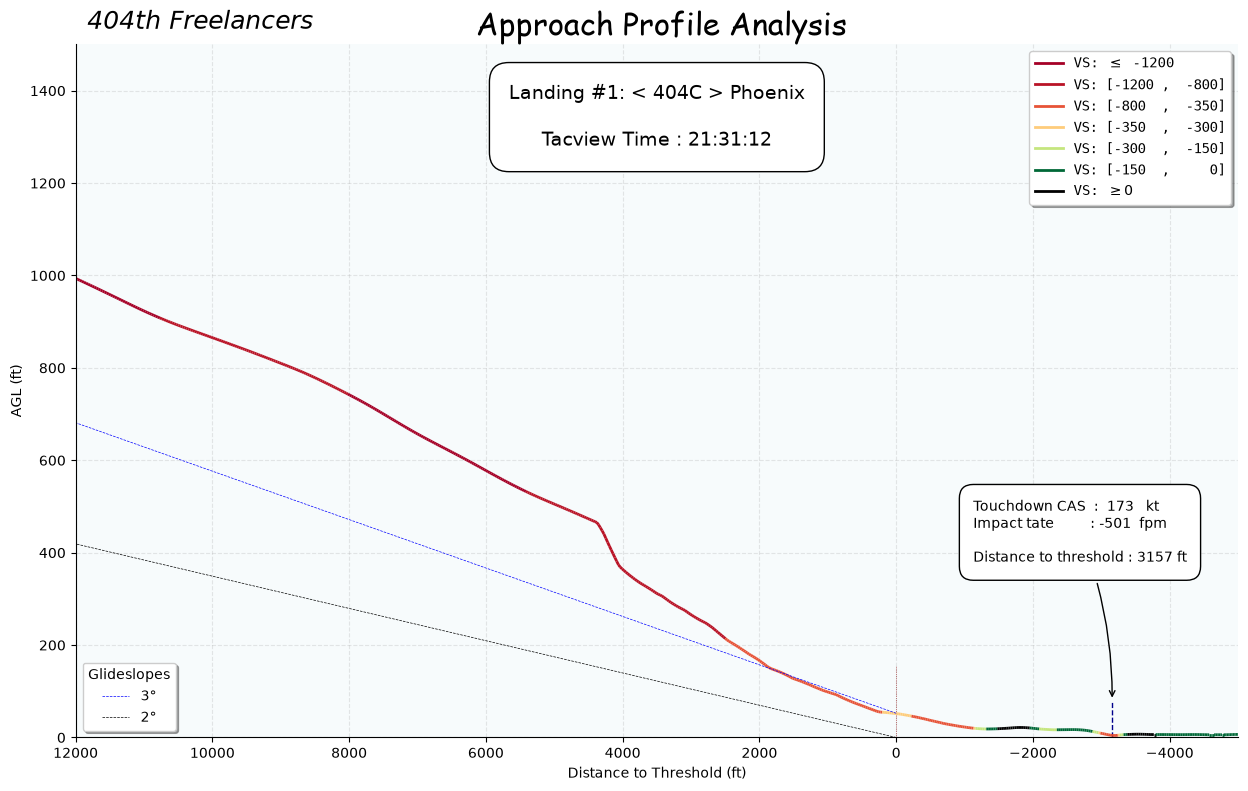

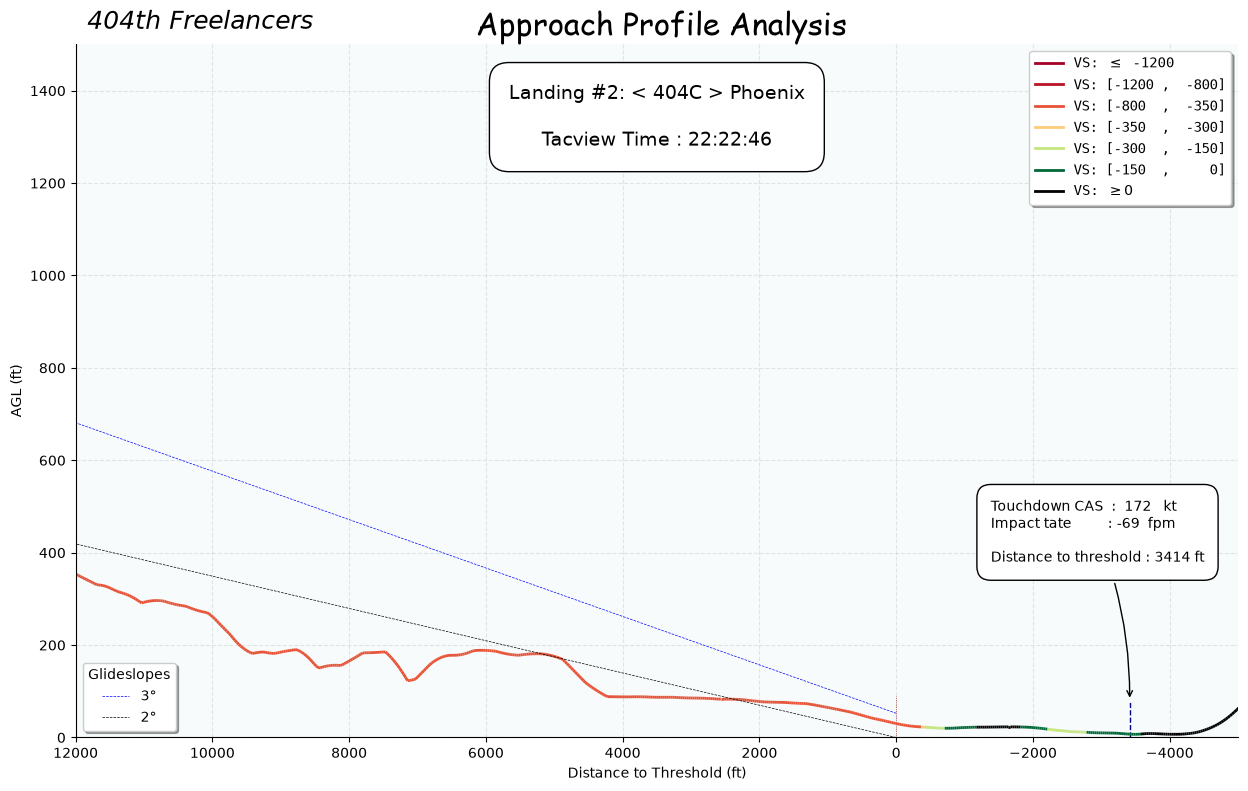

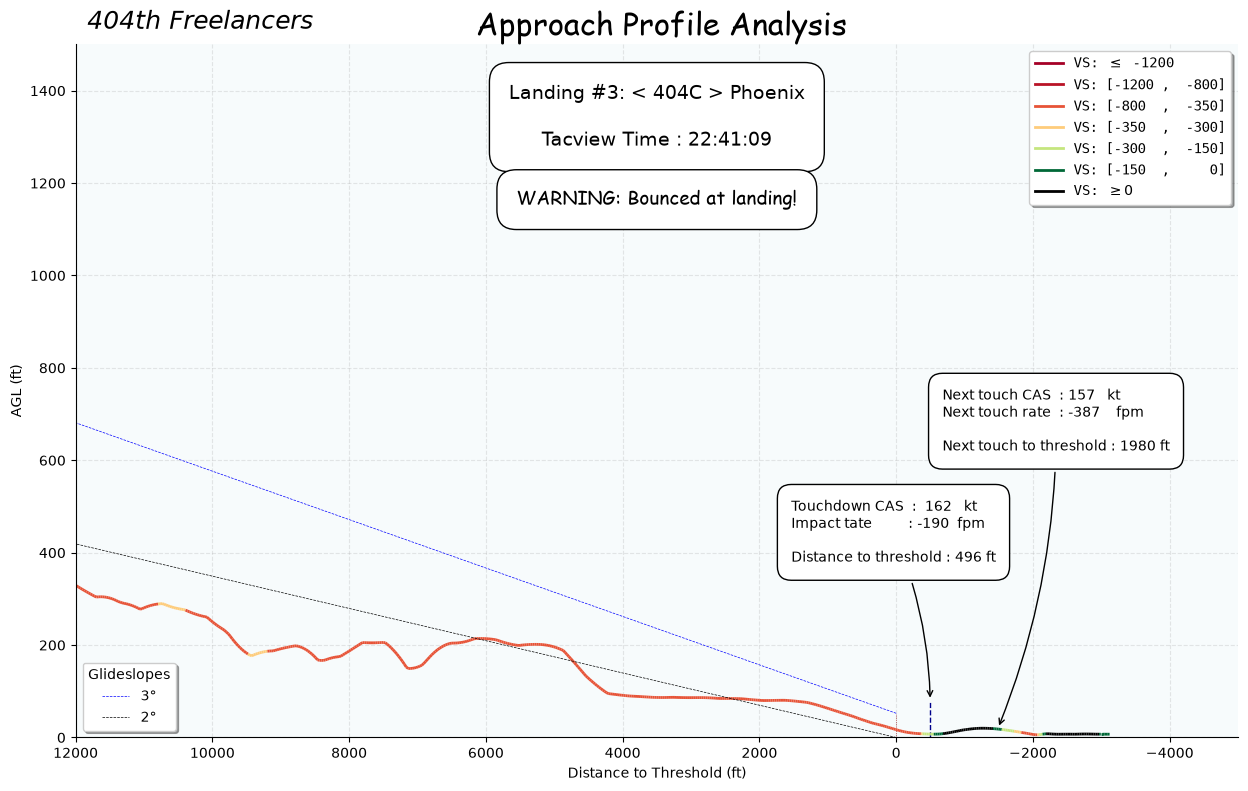

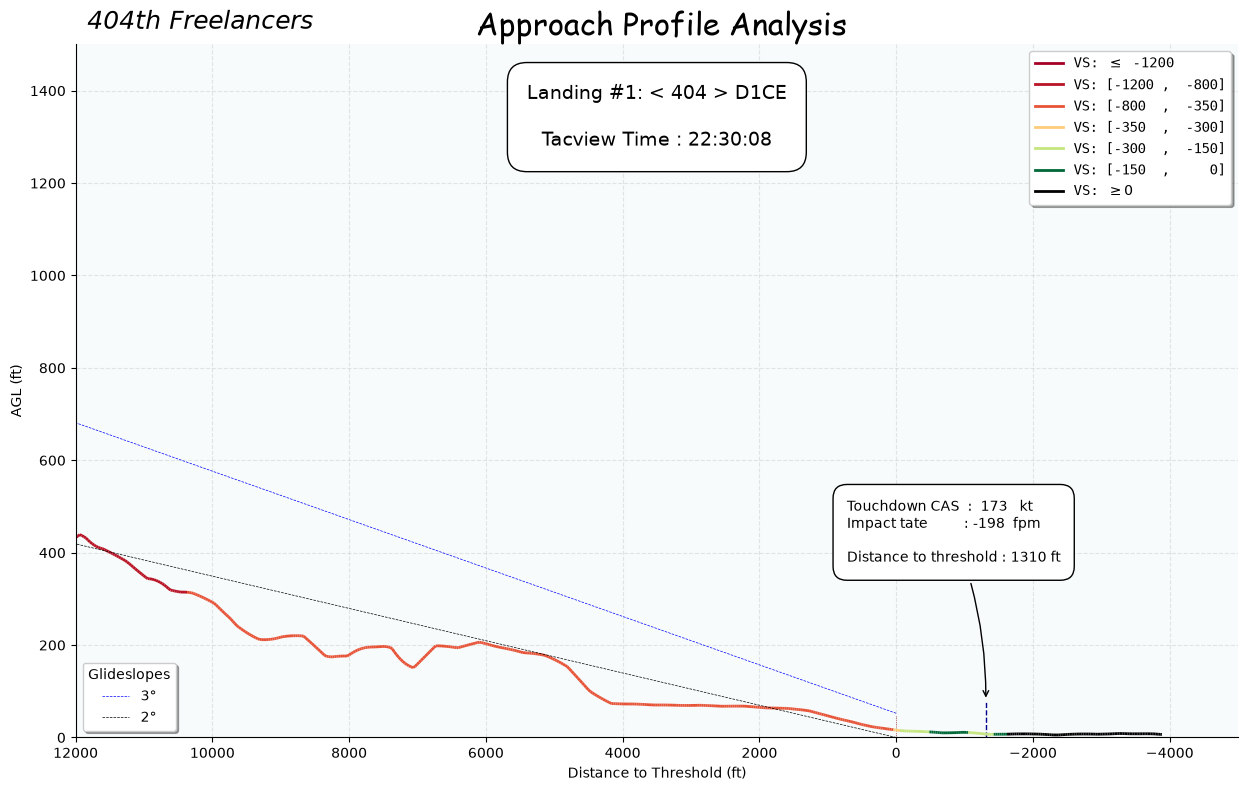

In [ ]:
# 3. Plot/Export Profiles

for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        plot_landing_profile(df_sub, df_result, pilot, sortie_num, plots_output_path)

## 5. Detailed Touchdowns (optional)

Sortie #4 of < 404C > Phoenix Took less than 6 second!


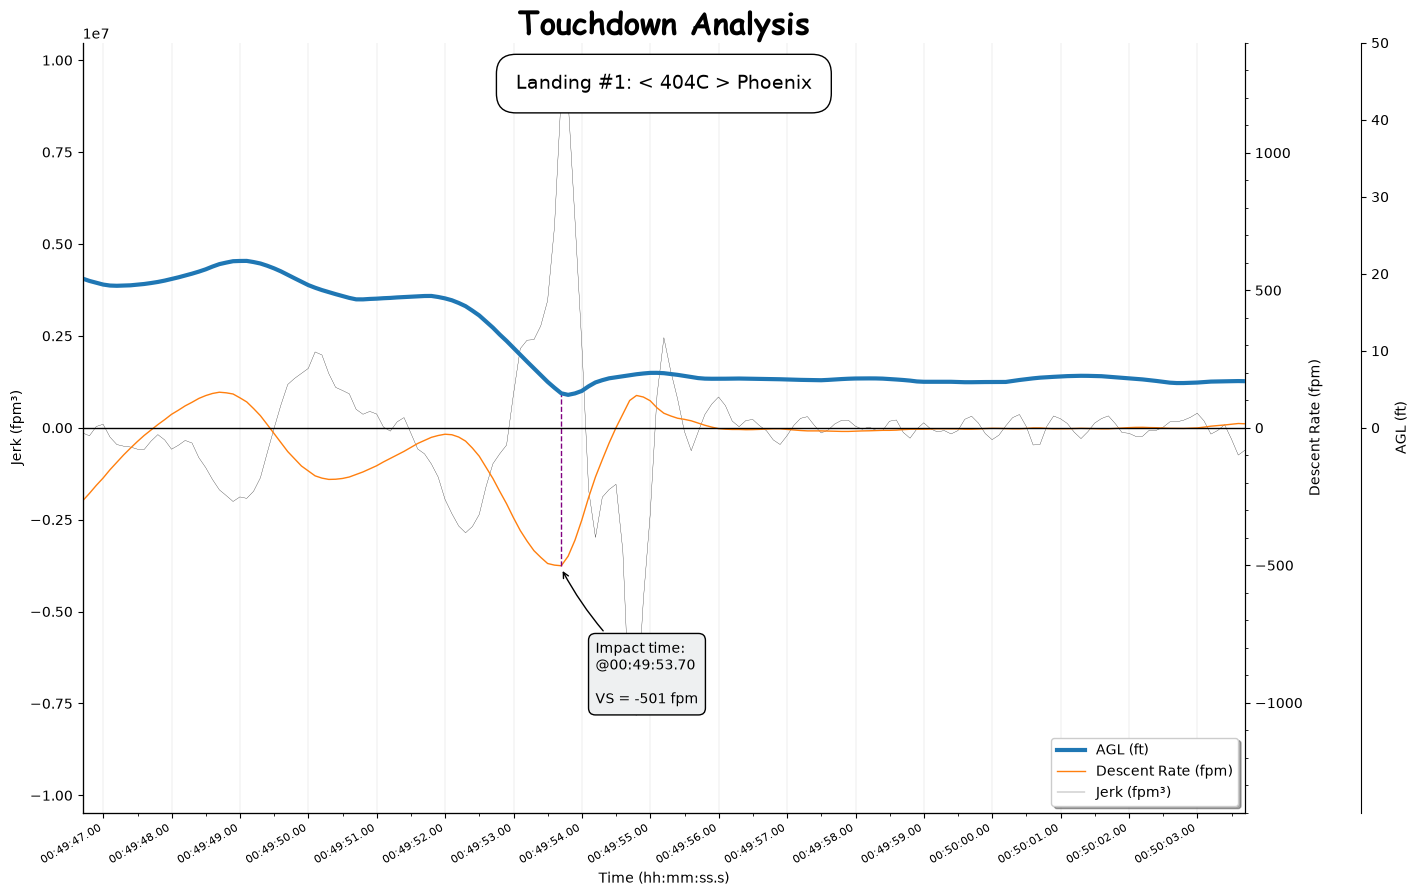

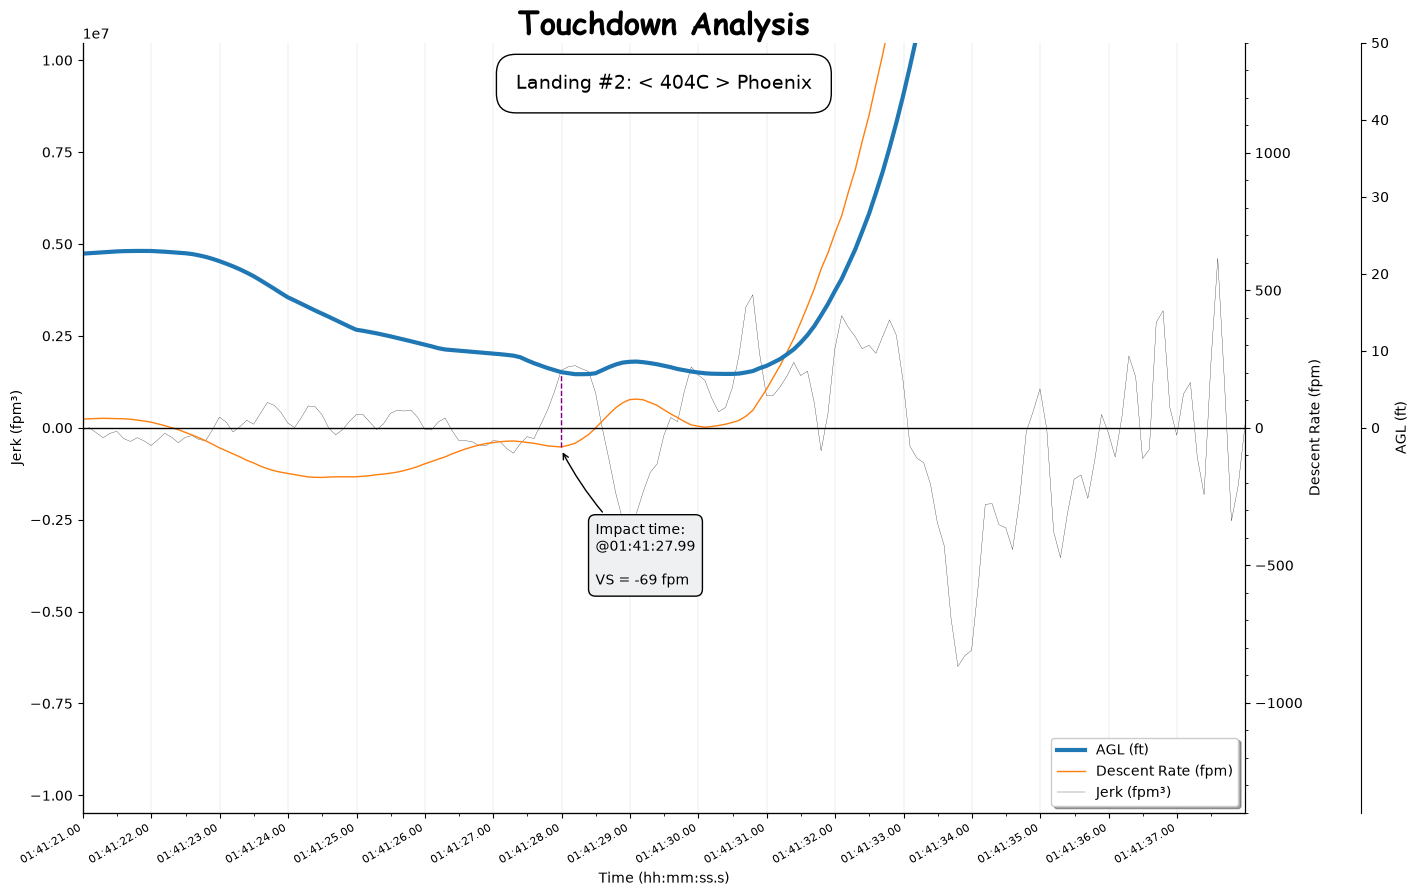

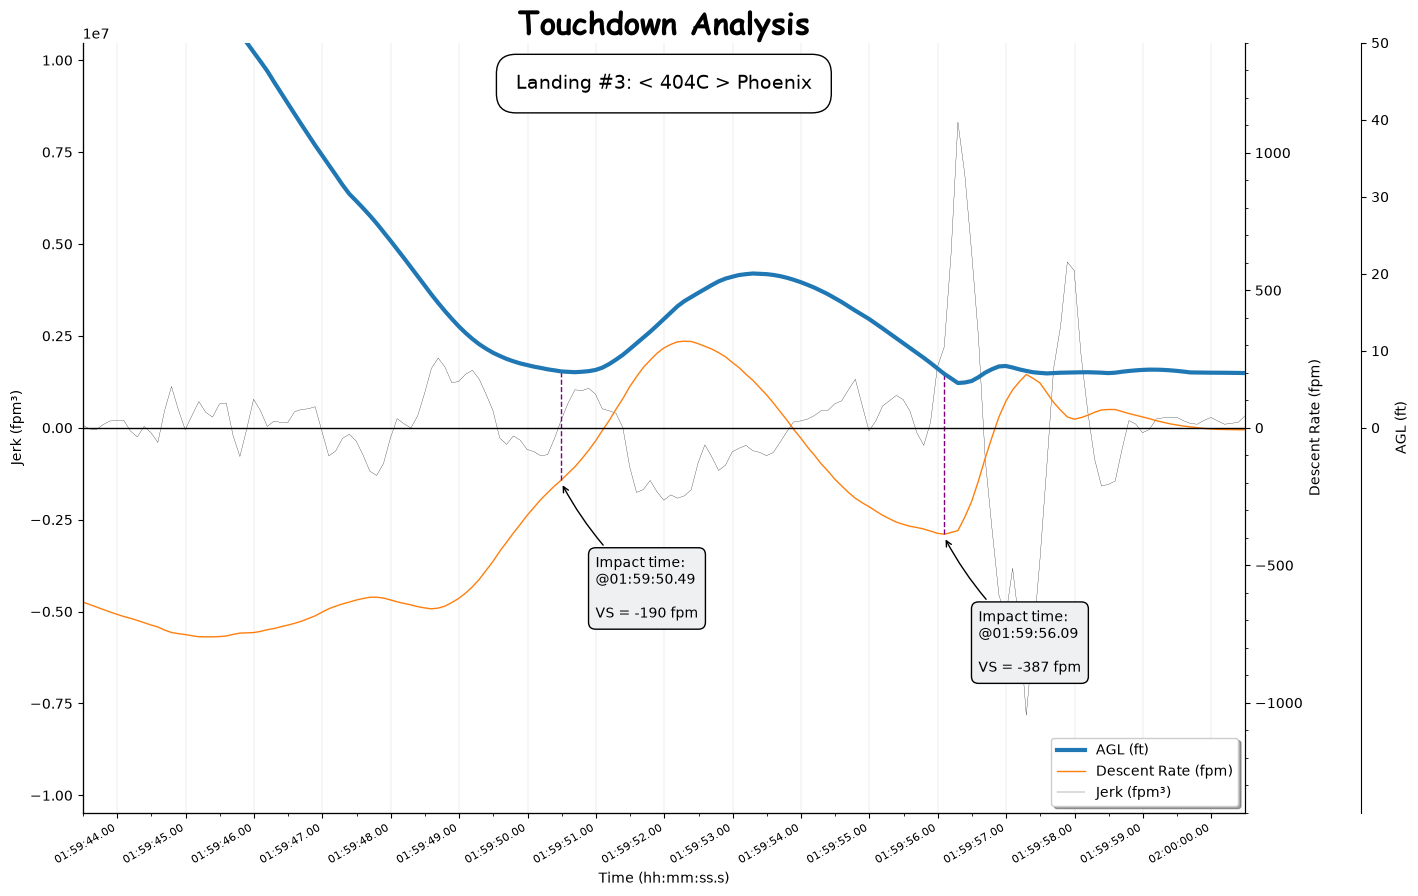

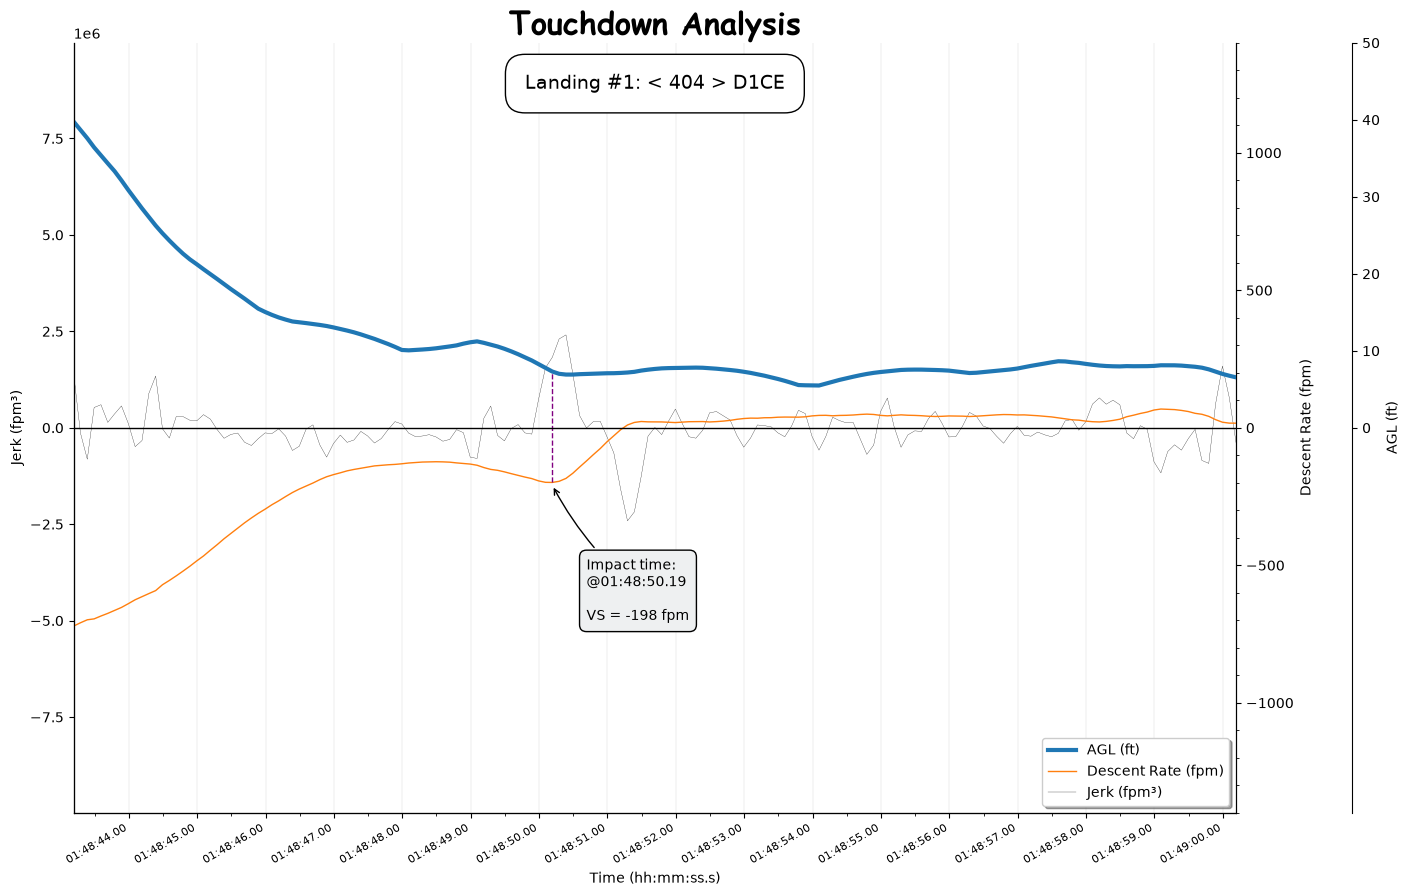

In [ ]:
# Plot/Export Touchdowns
for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(df_sub, df_result, pilot, sortie_num, detailed_td_path)